In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from multiprocessing import Pool
import glob

run = False

In [16]:
def symmetric_matrix(theta):
    # size of symmetric matrix
    n = int((np.sqrt(1 + 8 * len(theta)) - 1) / 2)
    if len(theta) != n * (n + 1) // 2:
        raise ValueError("Size of theta is invalid for a symmetric matrix")
    # init matrix by generating triangles and then diagonal
    matrix = np.zeros((n, n))
    triu_indices = np.triu_indices(n)
    matrix[triu_indices] = theta
    matrix = matrix + matrix.T - np.diag(np.diag(matrix))
    return np.matrix(matrix)

def extract_theta(symmetric_matrix):
    # extract and flatten to correct shape
    triu_indices = np.triu_indices(symmetric_matrix.shape[0])
    theta = symmetric_matrix[triu_indices]
    return np.array(theta).flatten()

In [17]:
def meta_int(X, t, betat, gamma, mu, Na):
    # solving odes for system
    S = X[:3]
    I = X[3:6]
    Theta = X[6:]
    beta = betat(t)
    Inf = (beta @ I) / Na

    dS = -Inf*S + (Na-S)*mu
    dI = Inf*S - (gamma+mu)*I
   
    # solving Lyapunov equation for covariance
    S = S/Na
    I = I/Na
    J_ss = np.diag([-mu-Inf[0],-mu-Inf[1],-mu-Inf[2]])
    J_si = -beta * S[:, np.newaxis]
    J_is = np.diag([Inf[0],Inf[1],Inf[2]])
    J_ii = -(mu+gamma)*np.eye(3) + beta * S[:, np.newaxis]
    A = np.block([[J_ss,J_si],[J_is,J_ii]])

    B_ss = np.diag([mu*(1-S[0])+S[0]*Inf[0],mu*(1-S[1])+S[1]*Inf[1],mu*(1-S[2])+S[2]*Inf[2]])
    B_si = np.diag([-mu*I[0]-S[0]*Inf[0],-mu*I[1]-S[1]*Inf[1],-mu*S[2]-S[2]*Inf[2]])
    B_ii = np.diag([(gamma+mu)*I[0]+S[0]*Inf[0],(gamma+mu)*I[1]+S[1]*Inf[1],(gamma+mu)*I[2]+S[2]*Inf[2]])
    B = np.block([[B_ss,B_si],[B_si,B_ii]])

    Θ = symmetric_matrix(Theta)
    K = A*Θ+Θ*A.transpose()+B
    return np.concatenate([dS,dI,extract_theta(K)])

$R_0=1/(\gamma+\mu)*\rho(\beta)$

In [18]:
# system parameters
gamma = 0.1
mu = 1/(80*365)
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
np.max(np.linalg.eigvals(beta_matrix))/(gamma+mu)

4.005684465099393

In [19]:
def gillespie_meta(N_cities,N_population,init_I,betat,gamma,mu,T_max):
    np.random.seed()
    # initialise variables and output arrays
    I = np.copy(init_I)
    S = np.full(N_cities, N_population) - I
    times = np.zeros(700000)
    St = np.zeros((700000,3))
    It = np.zeros((700000,3))
    St[0,:] = np.copy(S)
    It[0,:] = np.copy(I)

    t = 0
    ind = 0
    while t < T_max:          
        beta_matrix = betat(t)
        # compute rates and time step
        infection_rates = (beta_matrix @ I) * S / N_population
        recovery_rates = gamma * I
        birth_death_rates = mu * (N_population-S)
        
        total_rate = np.sum(infection_rates) + np.sum(recovery_rates) + np.sum(birth_death_rates)
        if total_rate == 0:
            break
        t += np.random.exponential(1 / total_rate)
        ind += 1

        # find event type and location (for b/d events)
        rand = np.random.rand() * total_rate
        if rand < infection_rates[0]:
            S[0] -= 1
            I[0] += 1
        elif rand < infection_rates[0] + infection_rates[1]:
            S[1] -= 1
            I[1] += 1
        elif rand < np.sum(infection_rates):
            S[2] -= 1
            I[2] += 1
        elif rand < np.sum(infection_rates) + recovery_rates[0]:
            I[0] -= 1
        elif rand < np.sum(infection_rates) + recovery_rates[0] + recovery_rates[1]:
            I[1] -= 1
        elif rand < np.sum(infection_rates) + np.sum(recovery_rates):
            I[2] -= 1
        elif rand < np.sum(infection_rates) + np.sum(recovery_rates) + birth_death_rates[0]:
            if np.random.rand() < I[0]/(N_population - S[0]):
                I[0] -= 1
            S[0] += 1
        elif rand < np.sum(infection_rates) + np.sum(recovery_rates) + birth_death_rates[0] + birth_death_rates[1]:
            if np.random.rand() < I[1]/(N_population - S[1]):
                I[1] -= 1
            S[1] += 1
        else:
            if np.random.rand() < I[2]/(N_population - S[2]):
                I[2] -= 1
            S[2] += 1
        # update output
        St[ind,:] = S
        It[ind,:] = I
        times[ind] = t
    return times[:ind+1], St[:ind+1], It[:ind+1]

## Constant $\beta$

In [20]:
# parameters
N_cities = 3
T_max = 100
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1
mu = 1/(80*365)
N_population = 100000

Ii = np.array([100,100,100])
Si = N_population - Ii

betat = lambda t: beta_matrix
days = np.arange(0,101,1)
ts = np.arange(0,100.1,0.1)
cst_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(cst_theory[i,6:])[3:,3:] for i in range(len(ts))]
cst_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(cst_theory[i,:3]*beta_matrix)) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_17722/2062679694.py:20: RuntimeWarning: invalid value encountered in scalar divide
  cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([272]),)

In [21]:
num_res = 100
def sim(alg, num):
    res = alg(N_cities,N_population,Ii,betat,gamma,mu,T_max)
    Is = np.array([np.interp(ts,res[0],res[2][:,i]) for i in range(3)])
    Ss = np.array([np.interp(ts,res[0],res[1][:,i]) for i in range(3)])
    np.save(f'Results/constant/S_{num}.npy',Ss)
    np.save(f'Results/constant/I_{num}.npy',Is)

runs = [(gillespie_meta, i) for i in range(num_res)]
if run:
    with Pool(8) as pool:
        res = pool.starmap(sim, runs)

In [22]:
file_paths = sorted(glob.glob("Results/constant/I*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
mean_per_time = data.mean(axis=0)
I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)

covariances = np.zeros((3, 3, 1001))
for t in range(1001):
    snapshot = mean_subtracted[:, :, t]
    covariances[:, :, t] = np.cov(snapshot, rowvar=False)
cst_sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
cst_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
cst_sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] for i in range(len(ts))])

file_paths = sorted(glob.glob("Results/constant/S*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
Reff_sims = np.mean(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*beta_matrix)) for j in range(len(ts))] for i in range(len(data))]),axis=0)
Reff_lb = np.quantile(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*beta_matrix)) for j in range(len(ts))] for i in range(len(data))]),q=[0.25,0.975],axis=0)

/tmp/ipykernel_17722/959903236.py:13: RuntimeWarning: invalid value encountered in scalar divide
  cst_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]


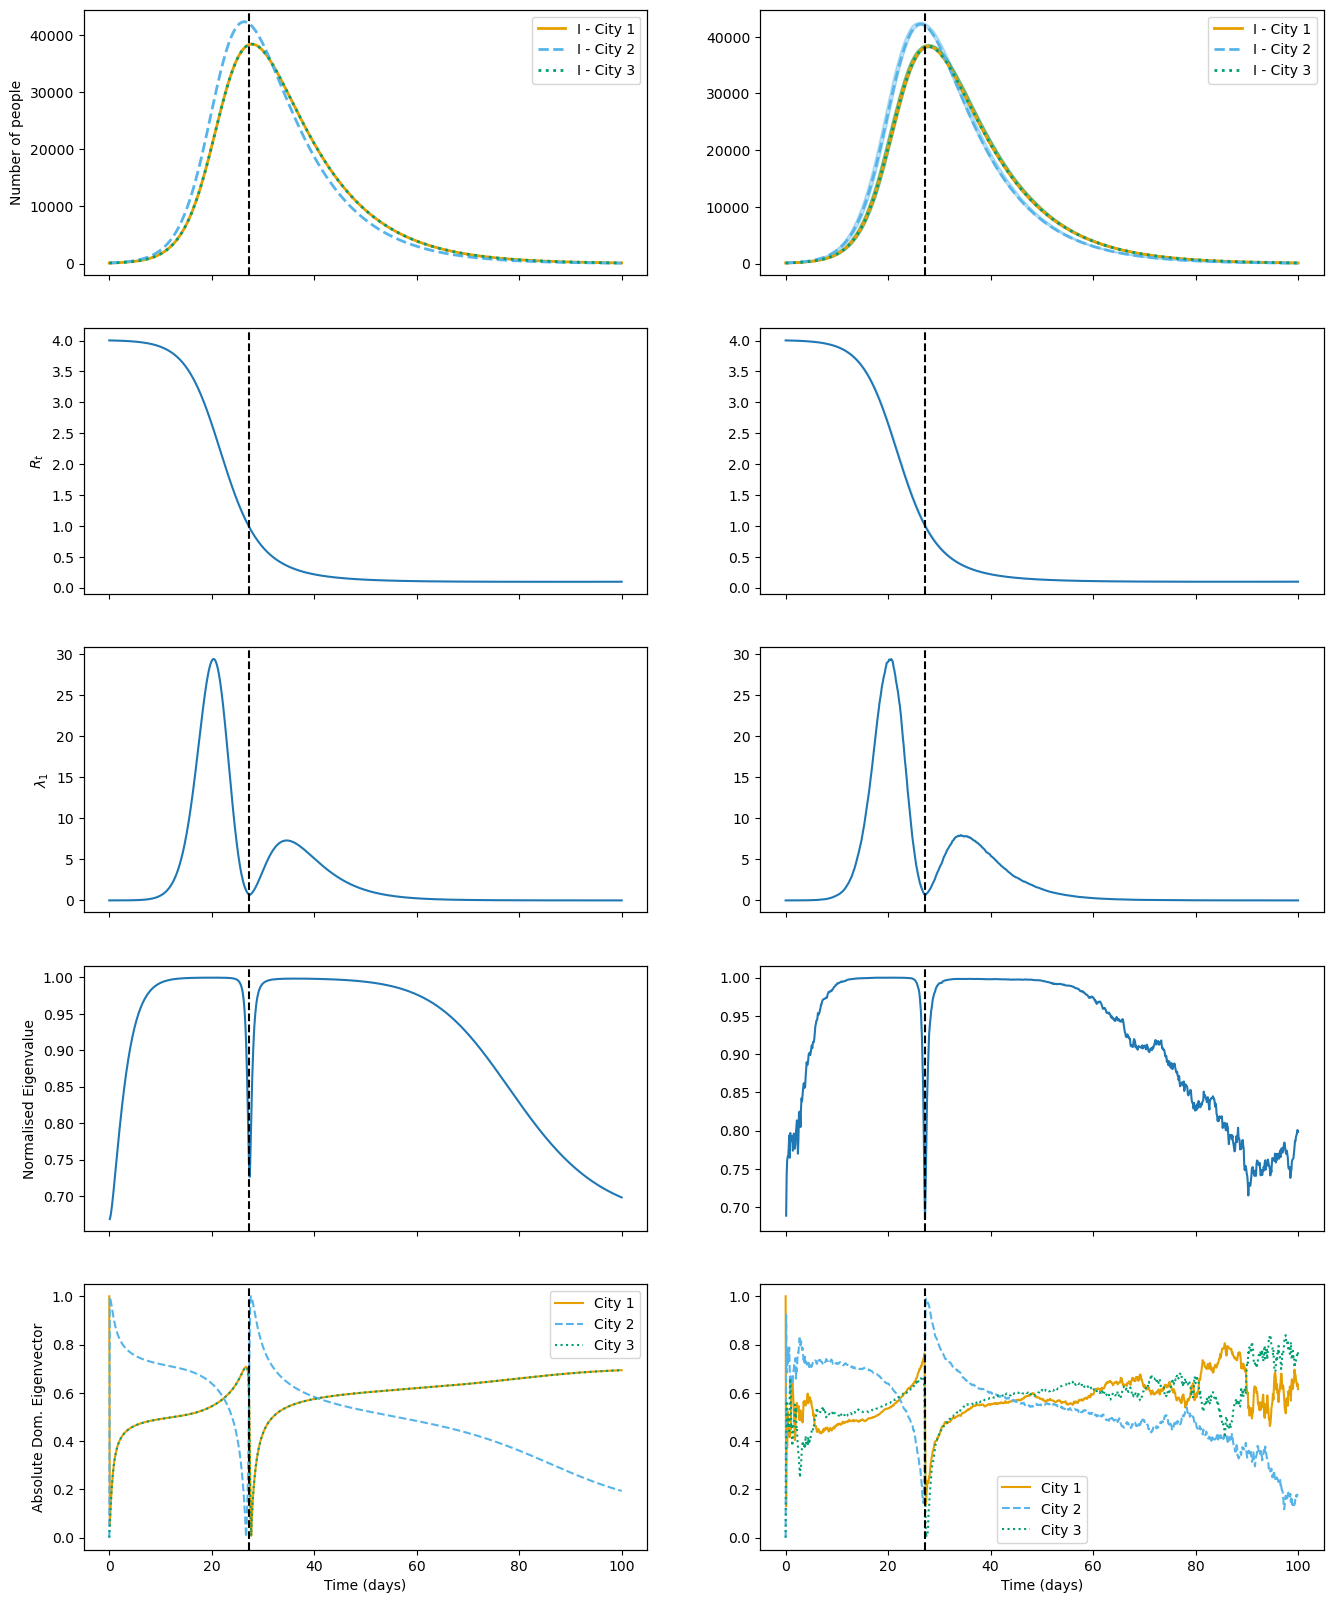

In [23]:
fig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,cst_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(cst_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(cst_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,cst_eigvals)
axs[0,3].plot(ts,cst_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,cst_sim_eigvals)
axs[1,3].plot(ts,cst_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
plt.savefig('Figures/cst_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()

## Just b[1,1], full epidemic

In [24]:
def betat(t):
    if t < 5:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.1*(t-5)*temp if (beta_matrix - 0.1*(t-5)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])

ts = np.arange(0,100.1,0.1)
in_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(in_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
in_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(in_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_17722/1090730005.py:12: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([332, 333]),)

In [25]:
num_res = 100
def sim(alg, num):
    res = alg(N_cities,N_population,Ii,betat,gamma,mu,T_max)
    Is = np.array([np.interp(ts,res[0],res[2][:,i]) for i in range(3)])
    Ss = np.array([np.interp(ts,res[0],res[1][:,i]) for i in range(3)])
    np.save(f'Results/dec/S_{num}.npy',Ss)
    np.save(f'Results/dec/I_{num}.npy',Is)

runs = [(gillespie_meta, i) for i in range(num_res)]
if run:
    with Pool(8) as pool:
        res = pool.starmap(sim, runs)

In [ ]:
file_paths = sorted(glob.glob("Results/dec/I*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
mean_per_time = data.mean(axis=0)
I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)

covariances = np.zeros((3, 3, 1001))
for t in range(1001):
    snapshot = mean_subtracted[:, :, t]
    covariances[:, :, t] = np.cov(snapshot, rowvar=False)
in_dec_sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
in_dec_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
in_dec_sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] for i in range(len(ts))])

file_paths = sorted(glob.glob("Results/dec/S*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
Reff_sims = np.mean(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(dfig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,spur_var_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(spur_var_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(spur_var_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,spur_var_eigvals)
axs[0,3].plot(ts,spur_var_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,spur_var_sim_eigvals)
axs[1,3].plot(ts,spur_var_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
plt.savefig('Figures/new_var_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()ata[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),axis=0)
Reff_lb = np.quantile(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),q=[0.25,0.975],axis=0)

/tmp/ipykernel_17722/1667370569.py:13: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]


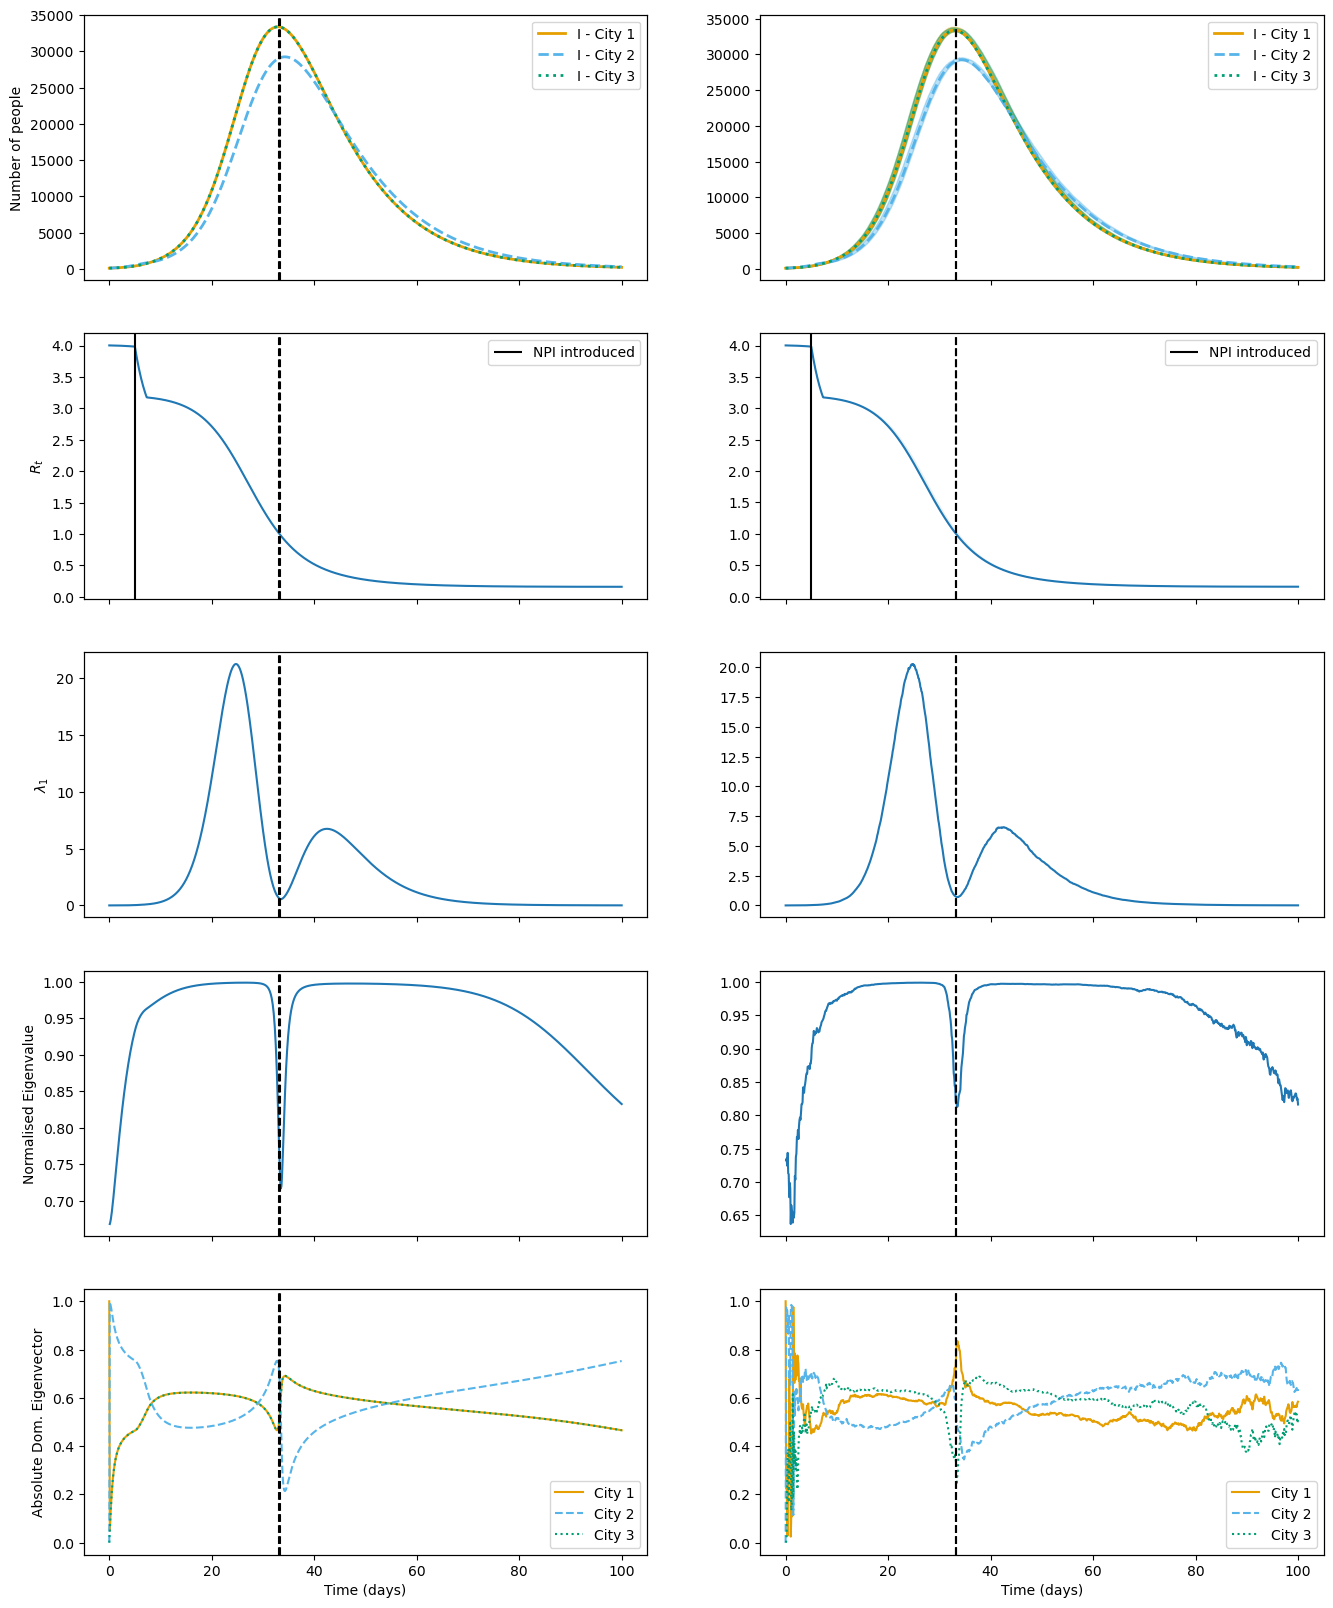

In [27]:
fig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,in_dec_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(in_dec_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(in_dec_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,in_dec_eigvals)
axs[0,3].plot(ts,in_dec_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,in_dec_sim_eigvals)
axs[1,3].plot(ts,in_dec_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(5,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(5,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
plt.savefig('Figures/in_city_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()

## Between cities

In [28]:
def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

ts = np.arange(0,100.1,0.1)
bet_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(bet_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
bet_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(bet_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_17722/1117251583.py:12: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([344, 345]),)

In [29]:
num_res = 100
def sim(alg, num):
    res = alg(N_cities,N_population,Ii,betat,gamma,mu,T_max)
    Is = np.array([np.interp(ts,res[0],res[2][:,i]) for i in range(3)])
    Ss = np.array([np.interp(ts,res[0],res[1][:,i]) for i in range(3)])
    np.save(f'Results/bet/S_{num}.npy',Ss)
    np.save(f'Results/bet/I_{num}.npy',Is)

runs = [(gillespie_meta, i) for i in range(num_res)]
if run:
    with Pool(8) as pool:
        res = pool.starmap(sim, runs)

In [30]:
file_paths = sorted(glob.glob("Results/bet/I*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
mean_per_time = data.mean(axis=0)
I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)

covariances = np.zeros((3, 3, 1001))
for t in range(1001):
    snapshot = mean_subtracted[:, :, t]
    covariances[:, :, t] = np.cov(snapshot, rowvar=False)
bet_dec_sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
bet_dec_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
bet_dec_sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] for i in range(len(ts))])

file_paths = sorted(glob.glob("Results/bet/S*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
Reff_sims = np.mean(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),axis=0)
Reff_lb = np.quantile(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),q=[0.25,0.975],axis=0)

/tmp/ipykernel_17722/2149361374.py:13: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]


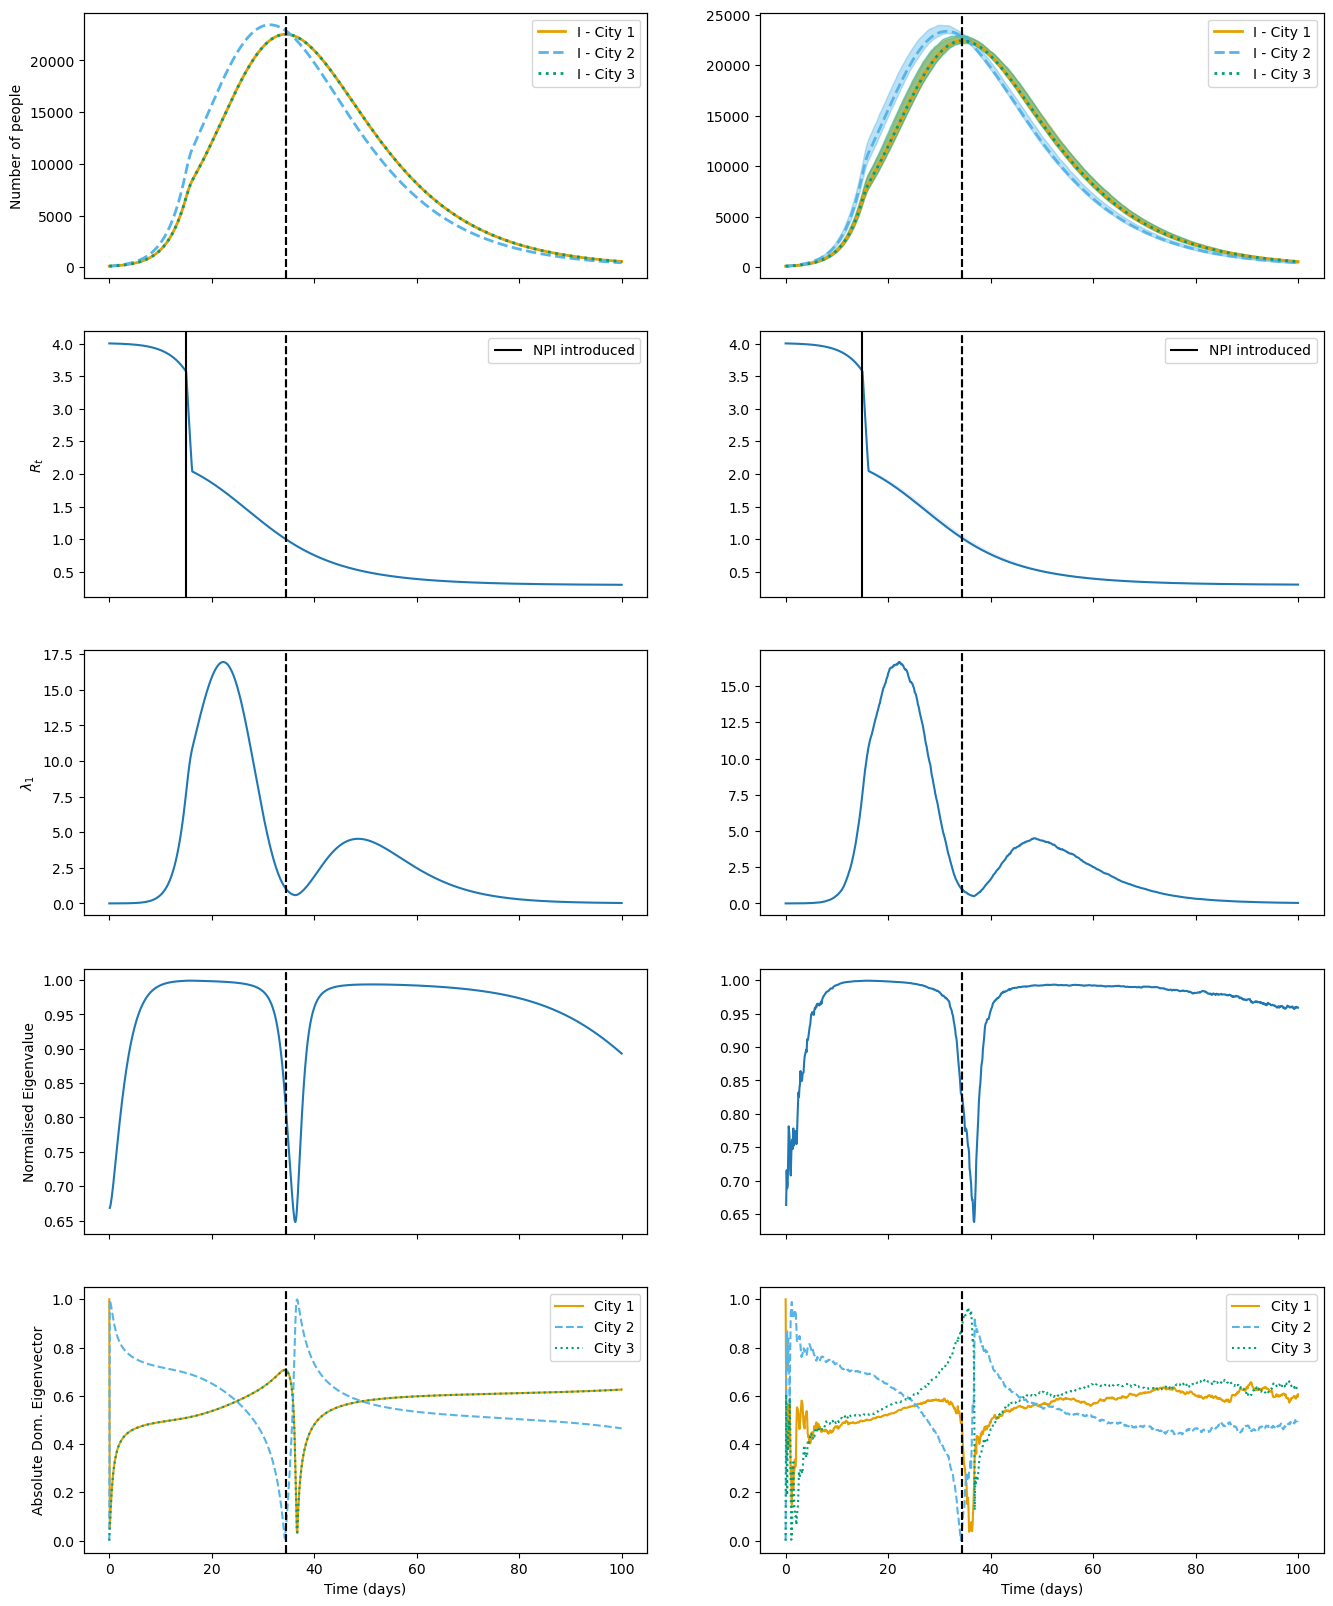

In [31]:
fig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,bet_dec_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(bet_dec_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(bet_dec_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,bet_dec_eigvals)
axs[0,3].plot(ts,bet_dec_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,bet_dec_sim_eigvals)
axs[1,3].plot(ts,bet_dec_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
plt.savefig('Figures/bet_city_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()

## New variant

In [32]:
N_cities = 3
T_max = 100
N_population = 100000

Ii = np.array([100,100,100])
Si = N_population - Ii


gamma = 0.1
mu = 1/(80*365)
b_w_l = 0.05
b_b_l = 0.025
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu)

0.8532611778611298


1.3303954541400647

In [33]:
def betat(t):
    b_w_l = 0.05
    b_b_l = 0.025
    beta_matrix_low = np.array([[b_w_l, b_b_l, 0],
                                [b_b_l, b_w_l, b_b_l],
                                [0,     b_b_l, b_w_l]])
    if t < 15:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],
                         [0,0,0.25],
                         [0,0,1]])
        return beta_matrix_low + 0.005*(t-15)*temp

ts = np.arange(0,100.1,0.1)
spur_var_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(spur_var_theory[i,6:])[3:,3:] for i in range(len(ts))]
spur_var_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(spur_var_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_17722/112580530.py:19: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([206, 207, 208, 209, 210, 811, 812]),)

In [34]:
num_res = 100
tstep_max = 0.01
def sim(alg, num):
    res = alg(N_cities,N_population,Ii,betat,gamma,mu,T_max)
    Is = np.array([np.interp(ts,res[0],res[2][:,i]) for i in range(3)])
    Ss = np.array([np.interp(ts,res[0],res[1][:,i]) for i in range(3)])
    np.save(f'Results/var/S_{num}.npy',Ss)
    np.save(f'Results/var/I_{num}.npy',Is)
if run:
    runs = [(gillespie_meta, i) for i in range(num_res)]
    with Pool(8) as pool:
        res = pool.starmap(sim, runs)

In [35]:
file_paths = sorted(glob.glob("Results/var/I*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
mean_per_time = data.mean(axis=0)
I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)

covariances = np.zeros((3, 3, 1001))
for t in range(1001):
    snapshot = mean_subtracted[:, :, t]
    covariances[:, :, t] = np.cov(snapshot, rowvar=False)
spur_var_sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
spur_var_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
spur_var_sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] for i in range(len(ts))])

file_paths = sorted(glob.glob("Results/var/S*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
Reff_sims = np.mean(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),axis=0)
Reff_lb = np.quantile(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),q=[0.25,0.975],axis=0)

/tmp/ipykernel_17722/3647550084.py:13: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]


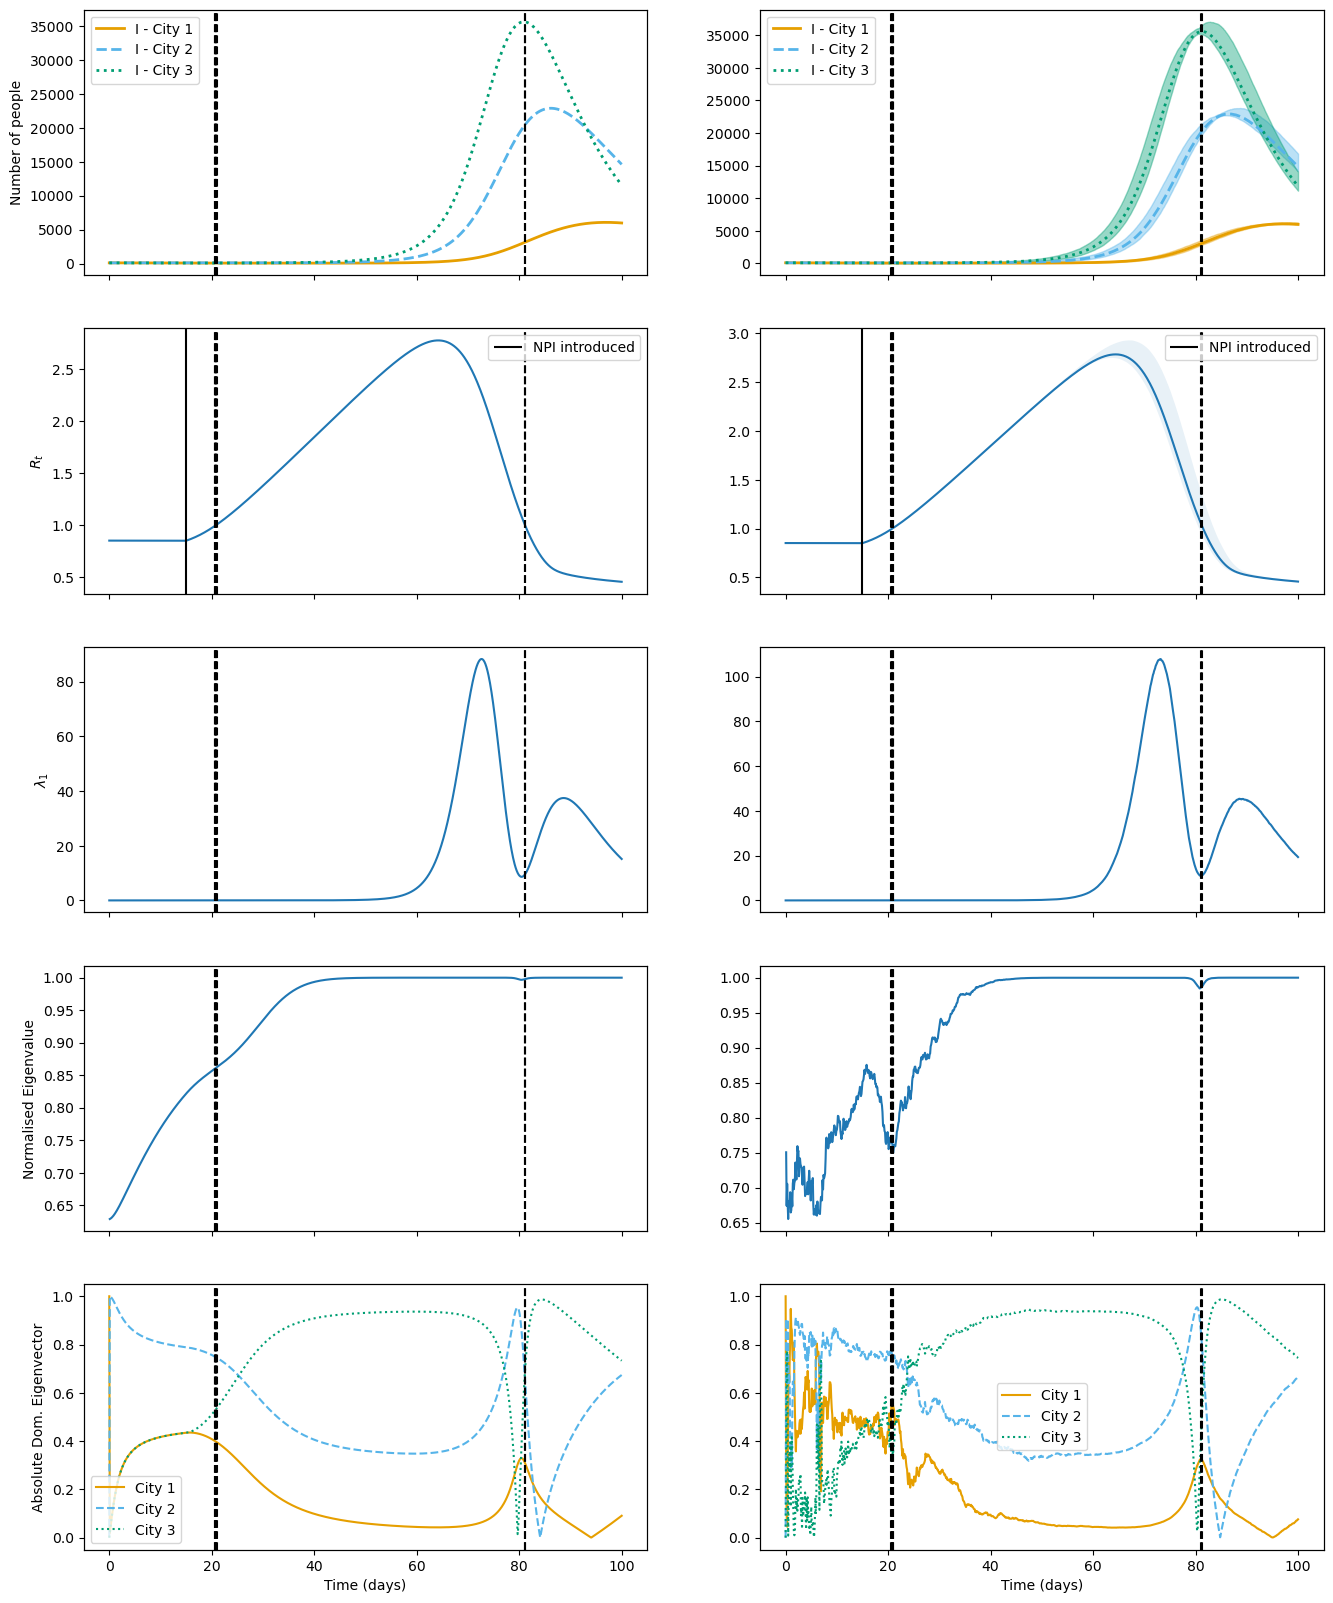

In [36]:
fig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,spur_var_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(spur_var_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(spur_var_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,spur_var_eigvals)
axs[0,3].plot(ts,spur_var_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,spur_var_sim_eigvals)
axs[1,3].plot(ts,spur_var_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    if i == 1:
        ax.vlines(15,ymin=0,ymax=1,linestyles='-',colors='k',label='NPI introduced')
        ax.legend()
plt.savefig('Figures/new_var_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()

## (Re-)Emergence

In [37]:
N_cities = 3
T_max = 100
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1
mu = 1/(80*365)
N_population = 100000

Ii = np.array([0,0,100])
Si = N_population - Ii

betat = lambda t: beta_matrix
days = np.arange(0,101,1)
ts = np.arange(0,100.1,0.1)
seed_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(seed_theory[i,6:])[3:,3:] for i in range(len(ts))]
seed_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
seed_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
seed_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(seed_theory[i,:3]*beta_matrix)) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_17722/140486095.py:19: RuntimeWarning: invalid value encountered in scalar divide
  seed_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([313]),)

In [38]:
num_res = 100
tstep_max = 0.01
def sim(alg, num):
    res = alg(N_cities,N_population,Ii,betat,gamma,mu,T_max)
    Is = np.array([np.interp(ts,res[0],res[2][:,i]) for i in range(3)])
    Ss = np.array([np.interp(ts,res[0],res[1][:,i]) for i in range(3)])
    np.save(f'Results/seed/S_{num}.npy',Ss)
    np.save(f'Results/seed/I_{num}.npy',Is)
if run:
    runs = [(gillespie_meta, i) for i in range(num_res)]
    with Pool(8) as pool:
        res = pool.starmap(sim, runs)

In [39]:
file_paths = sorted(glob.glob("Results/seed/I*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
mean_per_time = data.mean(axis=0)
I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)

covariances = np.zeros((3, 3, 1001))
for t in range(1001):
    snapshot = mean_subtracted[:, :, t]
    covariances[:, :, t] = np.cov(snapshot, rowvar=False)
seed_sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
seed_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
seed_sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] for i in range(len(ts))])

file_paths = sorted(glob.glob("Results/seed/S*.npy"))
data_list = [np.load(fp) for fp in file_paths]
data = np.stack(data_list, axis=0)
Reff_sims = np.mean(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),axis=0)
Reff_lb = np.quantile(np.array([[1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(data[i,:,j]*betat(ts[j]))) for j in range(len(ts))] for i in range(len(data))]),q=[0.25,0.975],axis=0)

/tmp/ipykernel_17722/3151614068.py:13: RuntimeWarning: invalid value encountered in scalar divide
  seed_sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]


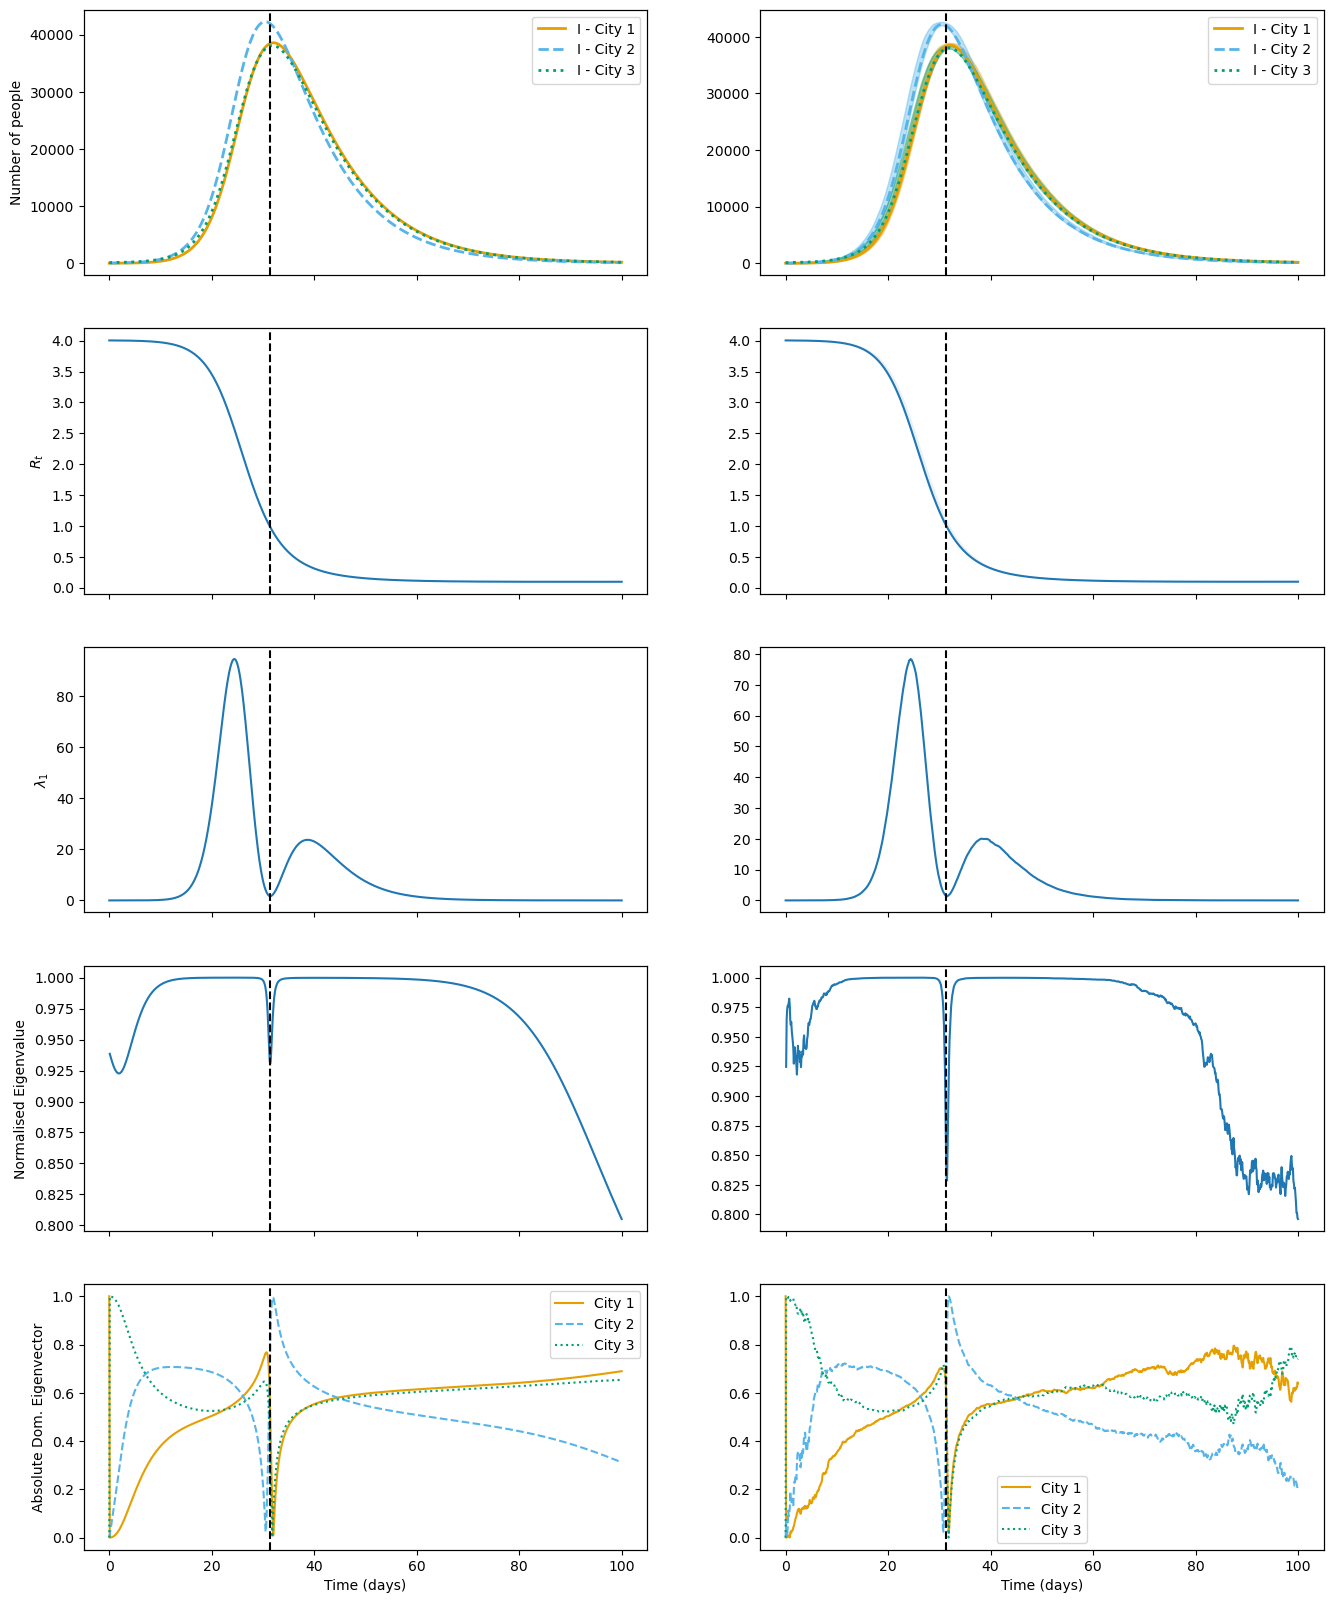

In [40]:
fig, axs = plt.subplots(nrows=5,ncols=2,figsize=(16,20),sharex=True)
linestyles = ['solid','dashed','dotted']
colors = ['#E69F00', '#56B4E9', '#009E73']
axs = axs.T
for i in range(3):
    axs[0,0].plot(ts,seed_theory[:,i+3],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[0,4].plot(ts,np.abs(seed_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].plot(ts,mean_per_time[i,:],linestyle=linestyles[i],color=colors[i],label=f'I - City {i+1}',linewidth=2)
    axs[1,4].plot(ts,np.abs(seed_sim_eigvec[:,i]),linestyle=linestyles[i],color=colors[i],label=f'City {i+1}')
    axs[1,0].fill_between(ts,I_lb[0,i],I_lb[1,i],color=colors[i],alpha=0.4)
axs[0,0].legend()
axs[0,4].legend()
axs[1,0].legend()
axs[1,4].legend()
axs[0,1].plot(ts,Reff)
axs[0,2].plot(ts,seed_eigvals)
axs[0,3].plot(ts,seed_norm_eigvals)
axs[1,1].plot(ts,Reff_sims)
axs[1,1].fill_between(ts,Reff_lb[0],Reff_lb[1],alpha=0.1)
axs[1,2].plot(ts,seed_sim_eigvals)
axs[1,3].plot(ts,seed_sim_norm_eigvals)
axs[0,0].set_ylabel('Number of people')
axs[0,1].set_ylabel(r'$R_t$')
axs[0,2].set_ylabel(r'$\lambda_1$')
axs[0,3].set_ylabel('Normalised Eigenvalue')
axs[0,4].set_ylabel('Absolute Dom. Eigenvector')
axs[0,-1].set_xlabel('Time (days)')
axs[1,-1].set_xlabel('Time (days)')
for i in range(len(axs[0])):
    ax = axs[0,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
    ax = axs[1,i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
    ax.set_yticks([])
plt.savefig('Figures/seed_theory.pdf',dpi=1200,bbox_inches='tight')
plt.show()